# Chapter 0: Pytorch Fundamentals

In [3]:
# import 
import torch

print(torch.__version__)

2.12.0+cpu


## I. Introduction to tensors

Tensors are the fundamental building block of machine learning. Their job is to represent data in a numerical way.

For example, you could represent an image as a tensor with shape `[3, 224, 224]` which would mean `[colour_channels, height, width]`, as in the image has 3 colour channels `(red, green, blue)`, a height of 224 pixels and a width of 224 pixels.

Reading more:
What are the difference of `PIL Images` and `OpenCV`?
- That is the order of 3 colour channel. PIL uses RGB, while OpenCV loads images as BGR by default.
- Also, PIL gives an image object, OpenCV gives a NumPy array.

### 1. Scalar
A scalar is a single number and in tensor-speak it's a zero dimension tensor.

In [4]:
# scalar is a signle number and a 0-dimensional tensor
scalar = torch.tensor(7) # establish a tensor
scalar

tensor(7)

In [5]:
scalar.ndim # to check the dimensions of the tensor

0

In [6]:
scalar.item() # to get the python number from a tensor (only works for single element tensors)

7

### 2. Vectors

A vector is a single dimension tensor but can contain many numbers.

As in, you could have a vector [3, 2] to describe [bedrooms, bathrooms] in your house. Or you could have [3, 2, 2] to describe [bedrooms, bathrooms, car_parks] in your house.

In [7]:
vector = torch.tensor([7, 7])
vector

tensor([7, 7])

In [8]:
vector.ndim

1

Another important concept for tensors is their shape attribute. The shape tells you how the elements inside them are arranged.

In [9]:
# Check shape of vector
vector.shape

torch.Size([2])

### 3. Matrix
Matrices are as flexible as vectors, except they've got an extra dimension.

MATRIX has two dimensions

In [10]:
# Matrix
MATRIX = torch.tensor([[7, 8], 
                       [9, 10]])
MATRIX

# Check number of dimensions
MATRIX.ndim

MATRIX.shape

torch.Size([2, 2])

### 4. Tensors 

Tensors represents nd-array. 


In [11]:
# Tensor
TENSOR = torch.tensor([[[1, 2, 3],
                        [3, 6, 9],
                        [2, 4, 5]]])
TENSOR

# Check number of dimensions for TENSOR
TENSOR.ndim

# Check shape of TENSOR
TENSOR.shape

torch.Size([1, 3, 3])

Alright, it outputs `torch.Size([1, 3, 3])`.

The dimensions go outer to inner.

That means there's 1 dimension of 3 by 3. (3x3)

> Note: You might've noticed me using lowercase letters for scalar and vector and uppercase letters for MATRIX and TENSOR. This was on purpose. In practice, you'll often see scalars and vectors denoted as lowercase letters such as y or a. And matrices and tensors denoted as uppercase letters such as X or W.

> You also might notice the names martrix and tensor used interchangably. This is common. Since in PyTorch you're often dealing with torch.Tensors (hence the tensor name), however, the shape and dimensions of what's inside will dictate what it actually is.

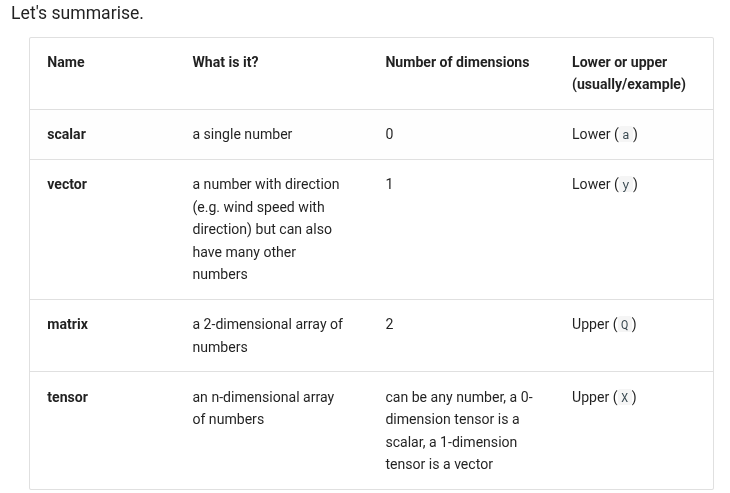

### 5. Random tensors

We've established tensors represent some form of data.

And machine learning models such as neural networks manipulate and seek patterns within tensors.

But when building machine learning models with PyTorch, it's rare you'll create tensors by hand (like what we've been doing).

Instead, a machine learning model often starts out with large random tensors of numbers and adjusts these random numbers as it works through data to better represent it.

In essence:

Start with random numbers -> look at data -> update random numbers -> look at data -> update random numbers...

As a data scientist, you can define how the machine learning model starts (initialization), looks at data (representation) and updates (optimization) its random numbers.

# We can do so using torch.rand() and passing in the size parameter.

# Create a random tensor of size (3, 4)
random_tensor = torch.rand(size=(3, 4))
random_tensor, random_tensor.dtype

The flexibility of torch.rand() is that we can adjust the size to be whatever we want.

For example, say you wanted a random tensor in the common image shape of [224, 224, 3] ([height, width, color_channels]).

In [12]:
# Create a random tensor of size (224, 224, 3)
random_image_size_tensor = torch.rand(size=(224, 224, 3))
random_image_size_tensor.shape, random_image_size_tensor.ndim
(torch.Size([224, 224, 3]), 3)

(torch.Size([224, 224, 3]), 3)

### 6. Zeros and ones 

Sometimes you'll just want to fill tensors with zeros or ones.

This happens a lot with masking (like masking some of the values in one tensor with zeros to let a model know not to learn them).

In [13]:
# Create a tensor of all zeros
zeros = torch.zeros(size=(3, 4))
zeros, zeros.dtype

(tensor([[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]),
 torch.float32)

In [14]:
# Create a tensor of all ones
ones = torch.ones(size=(3, 4))
ones, ones.dtype

(tensor([[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]),
 torch.float32)

### 7. Creating a range and tensors like
Sometimes you might want a range of numbers, such as 1 to 10 or 0 to 100.

You can use `torch.arange(start, end, step)` to do so.

Where:
- start = start of range (e.g. 0)
- end = end of range (e.g. 10)
- step = how many steps in between each value (e.g. 1)

> Note: In Python, you can use range() to create a range. However in PyTorch, torch.range() is deprecated and may show an error in the future.

In [15]:
# Use torch.arange(), torch.range() is deprecated 
zero_to_ten_deprecated = torch.range(0, 10) # Note: this may return an error in the future

# Create a range of values 0 to 10
zero_to_ten = torch.arange(start=0, end=10, step=1)
zero_to_ten

/tmp/ipykernel_45403/193451495.py:2: UserWarning: torch.range is deprecated and will be removed in a future release because its behavior is inconsistent with Python's range builtin. Instead, use torch.arange, which produces values in [start, end).
  zero_to_ten_deprecated = torch.range(0, 10) # Note: this may return an error in the future


tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

> Sometimes you might want one tensor of a certain type with the same shape as another tensor.

For example, a tensor of all zeros with the same shape as a previous tensor.

To do so you can use `torch.zeros_like(input)` or `torch.ones_like(input)` which return a tensor filled with zeros or ones in the same shape as the input respectively.

In [16]:
# Can also create a tensor of zeros similar to another tensor
ten_zeros = torch.zeros_like(input=zero_to_ten) # will have same shape
ten_zeros

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### 9. Tensor datatypes

There are many different tensor datatypes available in PyTorch.

Some are specific for CPU and some are better for GPU.

Getting to know which one can take some time.

Generally if you see `torch.cuda` anywhere, the tensor is being used for GPU (since Nvidia GPUs use a computing toolkit called CUDA).

The most common type (and generally the default) is `torch.float32 or torch.float`.

This is referred to as "32-bit floating point".

But there's also 16-bit floating point (`torch.float16 or torch.half`) and 64-bit floating point (`torch.float64 or torch.double`).

And to confuse things even more there's also 8-bit, 16-bit, 32-bit and 64-bit integers.

> Note: An integer is a flat round number like 7 whereas a float has a decimal 7.0.

The reason for all of these is to do with **precision in computing**.

Precision is the amount of detail used to describe a number.

The higher the precision value (8, 16, 32), the more detail and hence data used to express a number.

This matters in deep learning and numerical computing because you're making so many operations, the more detail you have to calculate on, the more compute you have to use.

So lower precision datatypes are generally faster to compute on but sacrifice some performance on evaluation metrics like accuracy (**faster to compute but less accurate**).

In [17]:
# Default datatype for tensors is float32
float_32_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype=None, # defaults to None, which is torch.float32 or whatever datatype is passed
                               device=None, # defaults to None, which uses the default tensor type
                               requires_grad=False) # if True, operations performed on the tensor are recorded 

float_32_tensor.shape, float_32_tensor.dtype, float_32_tensor.device

(torch.Size([3]), torch.float32, device(type='cpu'))

Aside from shape issues (tensor shapes don't match up), two of the other most common issues you'll come across in PyTorch are datatype and device issues.

For example, one of tensors is torch.float32 and the other is torch.float16 (PyTorch often likes tensors to be the same format).

Or one of your tensors is on the CPU and the other is on the GPU (PyTorch likes calculations between tensors to be on the same device).

We'll see more of this device talk later on.

In [18]:
float_16_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype=torch.float16) # torch.half would also work

float_16_tensor.dtype

torch.float16

## II. Getting information from tensors
Once you've created tensors (or someone else or a PyTorch module has created them for you), you might want to get some information from them.

We've seen these before but three of the most common attributes you'll want to find out about tensors are:

- `shape` - what shape is the tensor? (some operations require specific shape rules)
- `dtype` - what datatype are the elements within the tensor stored in?
- `device` - what device is the tensor stored on? (usually GPU or CPU)

In [19]:
# Create a tensor
some_tensor = torch.rand(3, 4)

# Find out details about it
print(some_tensor)
print(f"Shape of tensor: {some_tensor.shape}")
print(f"Datatype of tensor: {some_tensor.dtype}")
print(f"Device tensor is stored on: {some_tensor.device}") # will default to CPU

tensor([[0.0378, 0.8393, 0.0941, 0.6476],
        [0.5531, 0.5343, 0.8851, 0.6755],
        [0.5790, 0.0040, 0.1682, 0.6347]])
Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


> Note: When you run into issues in PyTorch, it's very often one to do with one of the three attributes above. So when the error messages show up, sing yourself a little song called "what, what, where":

**"what shape are my tensors? what datatype are they and where are they stored? what shape, what datatype, where where where"**

## III. Manipulating tensors (tensor operations)

In deep learning, data (images, text, video, audio, protein structures, etc) gets represented as tensors.

A model learns by investigating those tensors and performing a series of operations (could be 1,000,000s+) on tensors to create a representation of the patterns in the input data.

These operations are often a wonderful dance between:

- Addition
- Substraction
- Multiplication (element-wise)
- Division
- Matrix multiplication
- And that's it. Sure there are a few more here and there but these are the basic building blocks of neural networks.

Stacking these building blocks in the right way, you can create the most sophisticated of neural networks (just like lego!).

### 1. Basic operations

In [20]:
# Create a tensor of values and add a number to it
tensor = torch.tensor([1, 2, 3])
tensor + 10

# Multiply it by 10
tensor * 10

# Tensors don't change unless reassigned
tensor

# Subtract and reassign
tensor = tensor - 10
tensor

# Can also use torch functions
torch.multiply(tensor, 10)
# PyTorch also has a bunch of built-in functions like torch.mul() (short for multiplication) and torch.add() to perform basic operations.



tensor([-90, -80, -70])

However, it's more common to use the operator symbols like `*` instead of `torch.mul()`

In [21]:
# Element-wise multiplication (each element multiplies its equivalent, index 0->0, 1->1, 2->2)
print(tensor, "*", tensor)
print("Equals:", tensor * tensor)

tensor([-9, -8, -7]) * tensor([-9, -8, -7])
Equals: tensor([81, 64, 49])


### 2. Matrix multiplication (is all you need)
One of the most common operations in machine learning and deep learning algorithms (like neural networks) is matrix multiplication.

PyTorch implements matrix multiplication functionality in the torch.matmul() method.

The main two rules for matrix multiplication to remember are:

1. The inner dimensions must match:
- `(3, 2) @ (3, 2)` won't work
- `(2, 3) @ (3, 2)` will work
- `(3, 2) @ (2, 3)` will work

2. The resulting matrix has the shape of the outer dimensions:
- `(2, 3) @ (3, 2)` -> `(2, 2)`
- `(3, 2) @ (2, 3)` -> `(3, 3)`

> Note: "@" in Python is the symbol for matrix multiplication.

Resource: You can see all of the rules for matrix multiplication using `torch.matmul()` in the PyTorch documentation.



In [22]:
import torch
tensor = torch.tensor([1, 2, 3])
tensor.shape

torch.Size([3])

The difference between element-wise multiplication and matrix multiplication is the addition of values.

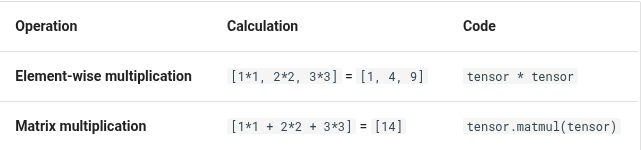

In [23]:
# Element-wise matrix multiplication
tensor * tensor

# Matrix multiplication
torch.matmul(tensor, tensor)

# Can also use the "@" symbol for matrix multiplication, though not recommended
tensor @ tensor

tensor(14)

You can do matrix multiplication by hand but it's not recommended.

The in-built `torch.matmul()` method is faster.

In [24]:
%%time
# Matrix multiplication by hand 
# (avoid doing operations with for loops at all cost, they are computationally expensive)
value = 0
for i in range(len(tensor)):
  value += tensor[i] * tensor[i]
value

CPU times: user 226 μs, sys: 864 μs, total: 1.09 ms
Wall time: 742 μs


tensor(14)

In [25]:
%%time
torch.matmul(tensor, tensor)

CPU times: user 158 μs, sys: 27 μs, total: 185 μs
Wall time: 145 μs


tensor(14)

## IV. One of the most common errors in deep learning (shape errors)

Because much of deep learning is multiplying and performing operations on matrices and matrices have a strict rule about what shapes and sizes can be combined, one of the most common errors you'll run into in deep learning is shape mismatches.

In [26]:
# Shapes need to be in the right way  
tensor_A = torch.tensor([[1, 2],
                        [3, 4],
                        [5, 6]], dtype=torch.float32)

tensor_B = torch.tensor([[7, 10],
                        [8, 11], 
                        [9, 12]], dtype=torch.float32)

# torch.matmul(tensor_A, tensor_B) # (this will error)  

We can make matrix multiplication work between `tensor_A` and `tensor_B` by making their inner dimensions match.

One of the ways to do this is with a **transpose** (switch the dimensions of a given tensor).

You can perform transposes in PyTorch using either:

- `torch.transpose(input, dim0, dim1)` - where input is the desired tensor to transpose and `dim0` and `dim1` are the dimensions to be swapped.
- `tensor.T` - where tensor is the desired tensor to transpose.

In [27]:
# View tensor_A and tensor_B
print(tensor_A)
print(tensor_B)

# View tensor_A and tensor_B.T
print(tensor_A)
print(tensor_B.T)

# The operation works when tensor_B is transposed
print(f"Original shapes: tensor_A = {tensor_A.shape}, tensor_B = {tensor_B.shape}\n")
print(f"New shapes: tensor_A = {tensor_A.shape} (same as above), tensor_B.T = {tensor_B.T.shape}\n")
print(f"Multiplying: {tensor_A.shape} * {tensor_B.T.shape} <- inner dimensions match\n")
print("Output:\n")
output = torch.matmul(tensor_A, tensor_B.T)
print(output) 
print(f"\nOutput shape: {output.shape}")

tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])
tensor([[ 7., 10.],
        [ 8., 11.],
        [ 9., 12.]])
tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])
tensor([[ 7.,  8.,  9.],
        [10., 11., 12.]])
Original shapes: tensor_A = torch.Size([3, 2]), tensor_B = torch.Size([3, 2])

New shapes: tensor_A = torch.Size([3, 2]) (same as above), tensor_B.T = torch.Size([2, 3])

Multiplying: torch.Size([3, 2]) * torch.Size([2, 3]) <- inner dimensions match

Output:

tensor([[ 27.,  30.,  33.],
        [ 61.,  68.,  75.],
        [ 95., 106., 117.]])

Output shape: torch.Size([3, 3])


You can also use `torch.mm()` which is a short for `torch.matmul()`.

> Note: A matrix multiplication like this is also referred to as the dot product of two matrices.

In [28]:
# torch.mm is a shortcut for matmul
torch.mm(tensor_A, tensor_B.T)

tensor([[ 27.,  30.,  33.],
        [ 61.,  68.,  75.],
        [ 95., 106., 117.]])

Neural networks are full of matrix multiplications and dot products.

The `torch.nn.Linear()` module (we'll see this in action later on), also known as a feed-forward layer or fully connected layer, implements a matrix multiplication between an input x and a weights matrix A.

$$y = x\cdot{A^T} + b$$

Where:

- x is the input to the layer (deep learning is a stack of layers like torch.nn.Linear() and others on top of each other).
- A is the weights matrix created by the layer, this starts out as random numbers that get adjusted as a neural network learns to better represent patterns in the data (notice the "T", that's because the weights matrix gets transposed).
> Note: You might also often see W or another letter like X used to showcase the weights matrix.
- b is the bias term used to slightly offset the weights and inputs.
- y is the output (a manipulation of the input in the hopes to discover patterns in it).

This is a linear function (you may have seen something like $y = mx+b$ in high school or elsewhere), and can be used to draw a straight line!

Let's play around with a linear layer.

Try changing the values of `in_features` and `out_features` below and see what happens.

Do you notice anything to do with the shapes?

In [29]:
# Since the linear layer starts with a random weights matrix, let's make it reproducible (more on this later)
torch.manual_seed(42)
# This uses matrix multiplication
linear = torch.nn.Linear(in_features=2, # in_features = matches inner dimension of input 
                         out_features=6) # out_features = describes outer value 
x = tensor_A
output = linear(x)
print(f"Input shape: {x.shape}\n")
print(f"Output:\n{output}\n\nOutput shape: {output.shape}")

Input shape: torch.Size([3, 2])

Output:
tensor([[2.2368, 1.2292, 0.4714, 0.3864, 0.1309, 0.9838],
        [4.4919, 2.1970, 0.4469, 0.5285, 0.3401, 2.4777],
        [6.7469, 3.1648, 0.4224, 0.6705, 0.5493, 3.9716]],
       grad_fn=<AddmmBackward0>)

Output shape: torch.Size([3, 6])


> Question: What happens if you change in_features from 2 to 3 above? Does it error? How could you change the shape of the input (x) to accommodate to the error? Hint: what did we have to do to tensor_B above?

### Finding the min, max, mean, sum, etc (aggregation)

Now we've seen a few ways to manipulate tensors, let's run through a few ways to aggregate them (go from more values to less values).

In [30]:
# Create a tensor
x = torch.arange(0, 100, 10)
x

tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

In [31]:
print(f"Minimum: {x.min()}")
print(f"Maximum: {x.max()}")
# print(f"Mean: {x.mean()}") # this will error
print(f"Mean: {x.type(torch.float32).mean()}") # won't work without float datatype
print(f"Sum: {x.sum()}")

Minimum: 0
Maximum: 90
Mean: 45.0
Sum: 450


> Note: You may find some methods such as `torch.mean()` require tensors to be in `torch.float32` (the most common) or another specific datatype, otherwise the operation will fail.

In [32]:
torch.max(x), torch.min(x), torch.mean(x.type(torch.float32)), torch.sum(x)

(tensor(90), tensor(0), tensor(45.), tensor(450))

### Positional min/max¶
You can also find the index of a tensor where the max or minimum occurs with `torch.argmax()` and `torch.argmin()` respectively.

This is helpful incase you just want the position where the highest (or lowest) value is and not the actual value itself (we'll see this in a later section when using the `softmax activation function`).

In [33]:
# Create a tensor
tensor = torch.arange(10, 100, 10)
print(f"Tensor: {tensor}")

# Returns index of max and min values
print(f"Index where max value occurs: {tensor.argmax()}")
print(f"Index where min value occurs: {tensor.argmin()}")

Tensor: tensor([10, 20, 30, 40, 50, 60, 70, 80, 90])
Index where max value occurs: 8
Index where min value occurs: 0


### Change tensor datatype

As mentioned, a common issue with deep learning operations is having your tensors in different datatypes.

If one tensor is in torch.float64 and another is in torch.float32, you might run into some errors.

But there's a fix.

You can change the datatypes of tensors using torch.Tensor.type(dtype=None) where the dtype parameter is the datatype you'd like to use.

In [35]:
# Create a tensor and check its datatype
tensor = torch.arange(10., 100., 10.)
print(tensor.dtype)

tensor_float16 = tensor.type(torch.float16)
print(tensor_float16)

# Create an int8 tensor
tensor_int8 = tensor.type(torch.int8)
print(tensor_int8)

torch.float32
tensor([10., 20., 30., 40., 50., 60., 70., 80., 90.], dtype=torch.float16)
tensor([10, 20, 30, 40, 50, 60, 70, 80, 90], dtype=torch.int8)


### Reshaping, stacking, squeezing and unsqueezing

Often times you'll want to reshape or change the dimensions of your tensors without actually changing the values inside them.

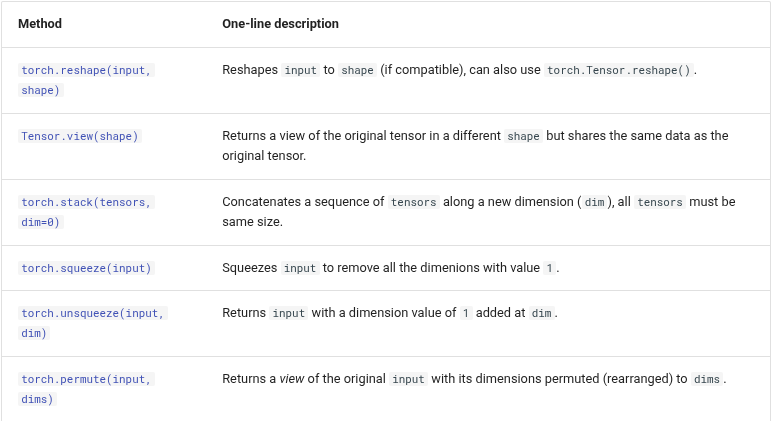

##### Why do any of these?

Because deep learning models (neural networks) are all about manipulating tensors in some way. And because of the rules of matrix multiplication, if you've got shape mismatches, you'll run into errors. These methods help you make sure the right elements of your tensors are mixing with the right elements of other tensors.


In [36]:
# Create a tensor
import torch
x = torch.arange(1., 8.)
x, x.shape

(tensor([1., 2., 3., 4., 5., 6., 7.]), torch.Size([7]))

In [37]:
# Add an extra dimension
x_reshaped = x.reshape(1, 7)
x_reshaped, x_reshaped.shape

(tensor([[1., 2., 3., 4., 5., 6., 7.]]), torch.Size([1, 7]))

In [38]:
# Change view (keeps same data as original but changes view)
# See more: https://stackoverflow.com/a/54507446/7900723
z = x.view(1, 7)
z, z.shape

(tensor([[1., 2., 3., 4., 5., 6., 7.]]), torch.Size([1, 7]))

In [39]:
# Changing z changes x
z[:, 0] = 5
z, x

(tensor([[5., 2., 3., 4., 5., 6., 7.]]), tensor([5., 2., 3., 4., 5., 6., 7.]))

In [45]:
# Stack tensors on top of each other
x_stacked = torch.stack([x, x, x, x], dim=0) # try changing dim to dim=1 and see what happens
x_stacked

tensor([[5., 2., 3., 4., 5., 6., 7.],
        [5., 2., 3., 4., 5., 6., 7.],
        [5., 2., 3., 4., 5., 6., 7.],
        [5., 2., 3., 4., 5., 6., 7.]])

How about removing all single dimensions from a tensor?

To do so you can use `torch.squeeze()` (I remember this as squeezing the tensor to only have dimensions over 1).

In [46]:
print(f"Previous tensor: {x_reshaped}")
print(f"Previous shape: {x_reshaped.shape}")

# Remove extra dimension from x_reshaped
x_squeezed = x_reshaped.squeeze()
print(f"\nNew tensor: {x_squeezed}")
print(f"New shape: {x_squeezed.shape}")

Previous tensor: tensor([[5., 2., 3., 4., 5., 6., 7.]])
Previous shape: torch.Size([1, 7])

New tensor: tensor([5., 2., 3., 4., 5., 6., 7.])
New shape: torch.Size([7])


You can also rearrange the order of axes values with `torch.permute(input, dims)`, where the input gets turned into a view with new `dims`.

In [47]:
# Create tensor with specific shape
x_original = torch.rand(size=(224, 224, 3))

# Permute the original tensor to rearrange the axis order
x_permuted = x_original.permute(2, 0, 1) # shifts axis 0->1, 1->2, 2->0

print(f"Previous shape: {x_original.shape}")
print(f"New shape: {x_permuted.shape}")

Previous shape: torch.Size([224, 224, 3])
New shape: torch.Size([3, 224, 224])


> Note: Because permuting returns a view (shares the same data as the original), the values in the permuted tensor will be the same as the original tensor and if you change the values in the view, it will change the values of the original.

## V. Indexing (selecting data from tensors)

Sometimes you'll want to select specific data from tensors (for example, only the first column or second row).

To do so, you can use indexing.

If you've ever done indexing on Python lists or NumPy arrays, indexing in PyTorch with tensors is very similar.

In [48]:
# Create a tensor 
import torch
x = torch.arange(1, 10).reshape(1, 3, 3)
x, x.shape

(tensor([[[1, 2, 3],
          [4, 5, 6],
          [7, 8, 9]]]),
 torch.Size([1, 3, 3]))

In [49]:
# Let's index bracket by bracket
print(f"First square bracket:\n{x[0]}") 
print(f"Second square bracket: {x[0][0]}") 
print(f"Third square bracket: {x[0][0][0]}")

First square bracket:
tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])
Second square bracket: tensor([1, 2, 3])
Third square bracket: 1


In [51]:
# Get all values of 0th dimension and the 0 index of 1st dimension
print(x[:, 0])

# Get all values of 0th & 1st dimensions but only index 1 of 2nd dimension
print(x[:, :, 1])

# Get all values of the 0 dimension but only the 1 index value of the 1st and 2nd dimension
print(x[:, 1, 1])

# Get index 0 of 0th and 1st dimension and all values of 2nd dimension 
print(x[0, 0, :]) # same as x[0][0]

tensor([[1, 2, 3]])
tensor([[2, 5, 8]])
tensor([5])
tensor([1, 2, 3])


## VI. PyTorch tensors & Numpy

Since NumPy is a popular Python numerical computing library, PyTorch has functionality to interact with it nicely.

The two main methods you'll want to use for NumPy to PyTorch (and back again) are:

- `torch.from_numpy(ndarray)` - NumPy array -> PyTorch tensor.
- `torch.Tensor.numpy()` - PyTorch tensor -> NumPy array.

In [52]:
# NumPy array to tensor
import torch
import numpy as np
array = np.arange(1.0, 8.0)
tensor = torch.from_numpy(array)
array, tensor

(array([1., 2., 3., 4., 5., 6., 7.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

> Note: By default, NumPy arrays are created with the datatype float64 and if you convert it to a PyTorch tensor, it'll keep the same datatype (as above). 

> However, many PyTorch calculations default to using float32.

> So if you want to convert your NumPy array (float64) -> PyTorch tensor (float64) -> PyTorch tensor (float32), you can use tensor = torch.from_numpy(array).type(torch.float32).

In [53]:
# Change the array, keep the tensor
array = array + 1
array, tensor

(array([2., 3., 4., 5., 6., 7., 8.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

In [54]:
# Tensor to NumPy array
tensor = torch.ones(7) # create a tensor of ones with dtype=float32
numpy_tensor = tensor.numpy() # will be dtype=float32 unless changed
tensor, numpy_tensor

(tensor([1., 1., 1., 1., 1., 1., 1.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

In [55]:
# Change the tensor, keep the array the same
tensor = tensor + 1
tensor, numpy_tensor

(tensor([2., 2., 2., 2., 2., 2., 2.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

### VII. Reproducibility (trying to take the random out of random)

As you learn more about neural networks and machine learning, you'll start to discover how much randomness plays a part.

Well, pseudorandomness that is. Because after all, as they're designed, a computer is fundamentally deterministic (each step is predictable) so the randomness they create are simulated randomness (though there is debate on this too, but since I'm not a computer scientist, I'll let you find out more yourself).

How does this relate to neural networks and deep learning then?

We've discussed neural networks start with random numbers to describe patterns in data (these numbers are poor descriptions) and try to improve those random numbers using tensor operations (and a few other things we haven't discussed yet) to better describe patterns in data.

In short:

`start with random numbers -> tensor operations -> try to make better (again and again and again)`

Although randomness is nice and powerful, sometimes you'd like there to be a little less randomness.

Why?

So you can perform repeatable experiments.

For example, you create an algorithm capable of achieving X performance.

And then your friend tries it out to verify you're not crazy.

How could they do such a thing?

That's where reproducibility comes in.

In other words, can you get the same (or very similar) results on your computer running the same code as I get on mine?



In [56]:
# Create two random tensors
random_tensor_A = torch.rand(3, 4)
random_tensor_B = torch.rand(3, 4)

print(f"Tensor A:\n{random_tensor_A}\n")
print(f"Tensor B:\n{random_tensor_B}\n")
print(f"Does Tensor A equal Tensor B? (anywhere)")
random_tensor_A == random_tensor_B

Tensor A:
tensor([[0.8016, 0.3649, 0.6286, 0.9663],
        [0.7687, 0.4566, 0.5745, 0.9200],
        [0.3230, 0.8613, 0.0919, 0.3102]])

Tensor B:
tensor([[0.9536, 0.6002, 0.0351, 0.6826],
        [0.3743, 0.5220, 0.1336, 0.9666],
        [0.9754, 0.8474, 0.8988, 0.1105]])

Does Tensor A equal Tensor B? (anywhere)


tensor([[False, False, False, False],
        [False, False, False, False],
        [False, False, False, False]])

Just as you might've expected, the tensors come out with different values.

But what if you wanted to create two random tensors with the same values.

As in, the tensors would still contain random values but they would be of the same flavour.

That's where `torch.manual_seed(seed)` comes in, where seed is an integer (like 42 but it could be anything) that flavours the randomness

In [59]:
import torch
import random

# # Set the random seed
RANDOM_SEED=42 # try changing this to different values and see what happens to the numbers below
torch.manual_seed(seed=RANDOM_SEED) 
random_tensor_C = torch.rand(3, 4)

# Have to reset the seed every time a new rand() is called 
# Without this, tensor_D would be different to tensor_C 
torch.random.manual_seed(seed=RANDOM_SEED) # try commenting this line out and seeing what happens
random_tensor_D = torch.rand(3, 4)

print(f"Tensor C:\n{random_tensor_C}\n")
print(f"Tensor D:\n{random_tensor_D}\n")
print(f"Does Tensor C equal Tensor D? (anywhere)")
random_tensor_C == random_tensor_D

Tensor C:
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])

Tensor D:
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])

Does Tensor C equal Tensor D? (anywhere)


tensor([[True, True, True, True],
        [True, True, True, True],
        [True, True, True, True]])